In [1]:
import torch
from torch import nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv, GATConv

C:\Users\praveenchakra.bh\AppData\Local\Programs\Python\Python39\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = Planetoid(root='datasets/Planetoid', name='Cora', transform=NormalizeFeatures())

In [3]:
print(f'Number of graphs: {len(dataset)}')
print(f'Number of features: {dataset.num_features}')
print(f'Number of classes: {dataset.num_classes}')

Number of graphs: 1
Number of features: 1433
Number of classes: 7


In [4]:
data = dataset[0]
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')

Number of nodes: 2708
Number of edges: 10556


In [5]:
print(data)

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


In [6]:
import torch.nn.functional as F

class GraphAttentionCNN(nn.Module):
    def __init__(self, hidden_channels, heads):
        super().__init__()
        self.hidden_channels = hidden_channels
        self.heads = heads
        self.conv1 = GATConv(dataset.num_features, self.hidden_channels, self.heads)
        self.conv2 = GATConv(self.hidden_channels * self.heads, dataset.num_classes, heads=1, concat=False)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=0.6, training=self.training)
        x = self.conv2(x, edge_index)
        return x

In [7]:
model = GraphAttentionCNN(hidden_channels=16, heads=4)

In [8]:
model

GraphAttentionCNN(
  (conv1): GATConv(1433, 16, heads=4)
  (conv2): GATConv(64, 7, heads=1)
)

In [9]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def visualize(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()

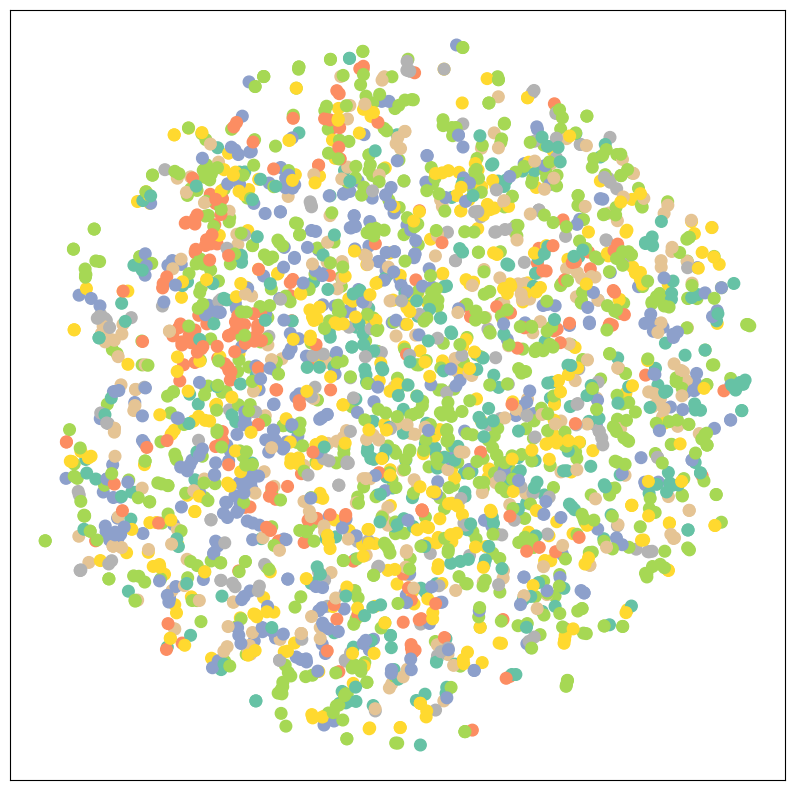

In [10]:
out = model(data.x, data.edge_index)
visualize(out, color=data.y)

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

In [12]:
from tqdm import tqdm

for epoch in tqdm(range(1, 101)):
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}')

  2%|▍                     | 2/100 [00:00<00:11,  8.83it/s]

Epoch: 001, Loss: 1.9457
Epoch: 002, Loss: 1.9257


  4%|▉                     | 4/100 [00:00<00:09,  9.60it/s]

Epoch: 003, Loss: 1.9074
Epoch: 004, Loss: 1.8828
Epoch: 005, Loss: 1.8616


  6%|█▎                    | 6/100 [00:00<00:09, 10.31it/s]

...

Epoch: 094, Loss: 0.2001
Epoch: 095, Loss: 0.2971
Epoch: 096, Loss: 0.2570


 98%|████████████████████▌| 98/100 [00:10<00:00,  9.35it/s]

Epoch: 097, Loss: 0.2685
Epoch: 098, Loss: 0.2728


100%|████████████████████| 100/100 [00:10<00:00,  9.71it/s]

Epoch: 099, Loss: 0.2750
Epoch: 100, Loss: 0.2369


In [13]:
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[data.test_mask] == data.y[data.test_mask]  # Check against ground-truth labels.
    test_acc = int(test_correct.sum()) / int(data.test_mask.sum())  # Derive ratio of correct predictions.
    return test_acc

In [14]:
test_acc = test()
print(f'Test Accuracy: {test_acc:.4f}')

Test Accuracy: 0.8050


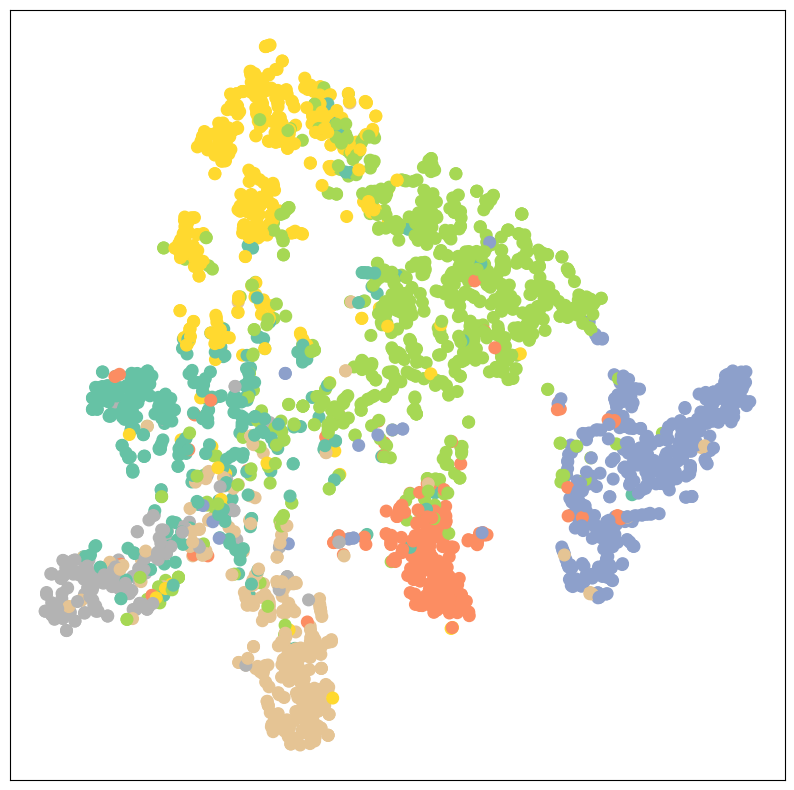

In [15]:
model.eval()

out = model(data.x, data.edge_index)
visualize(out, color=data.y)